In [1]:
from classes import Function, Convolution, PoissonProcess
from functions import neuron_kernel,sigmoid
import numpy as np

In [2]:
DELTA_T = 0.01
INTERVAL = 21.5

x_values = np.arange(0, INTERVAL , DELTA_T)
functions = [
                (1.5, lambda x: -1),
                (2, lambda x: 1),
                (2, lambda x: -1),
                (2, lambda x: 0),
                (5, lambda x: np.sin(np.pi * np.power(x,2))),
                (2, lambda x: 0),
                (5, lambda x: 0.2 * x * np.sin(3 * np.pi * x)),
                (2, lambda x: 0)
            ]

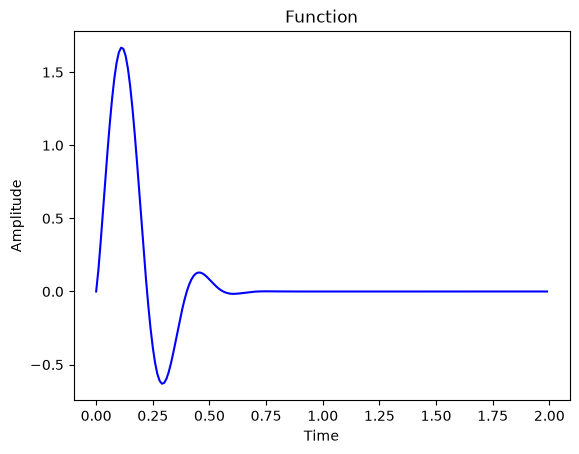

In [3]:
stimulus = Function(functions=functions, x_values=x_values)
# ON-fast-sustained
p = 1
l = 0.4
v = 1.2

neuron = Function(
    functions=[
        (2, neuron_kernel(p, l, v)) #2 seconds so the array dosen't get crazy long 
    ],
    x_values=np.arange(0, 2, DELTA_T)
)
neuron.graph()

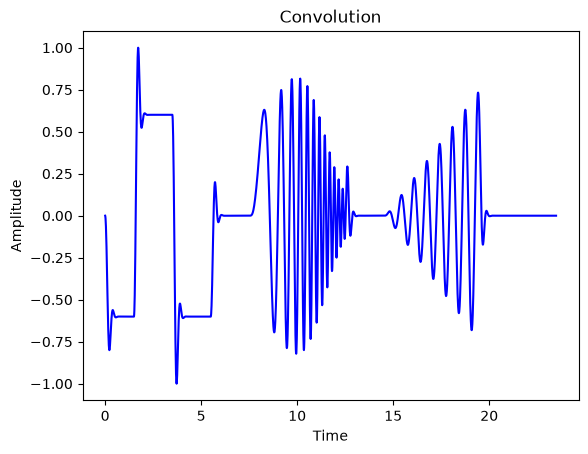

In [4]:
convolution = Convolution(stimulus, neuron, min_max=True, delta_t=DELTA_T)
convolution.graph()

In [5]:
convolution.y_values

array([ 0.        , -0.00532246, -0.01745553, ...,  0.        ,
        0.        ,  0.        ], shape=(2349,))

In [6]:
response = convolution.y_values[:len(x_values)]

rate_values = sigmoid(
    max_value=100,
    min_value=0.5,
    gain=4,
    offset=1,
)(response)

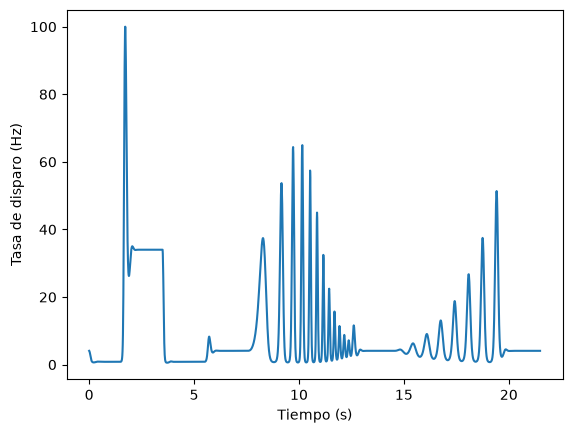

In [7]:
import matplotlib.pyplot as plt

plt.plot(x_values, rate_values)
plt.xlabel("Tiempo (s)")
plt.ylabel("Tasa de disparo (Hz)")
plt.show()

In [8]:
rate_values

array([4.07925578, 4.00518749, 3.84192345, ..., 4.07925578, 4.07925578,
       4.07925578], shape=(2150,))

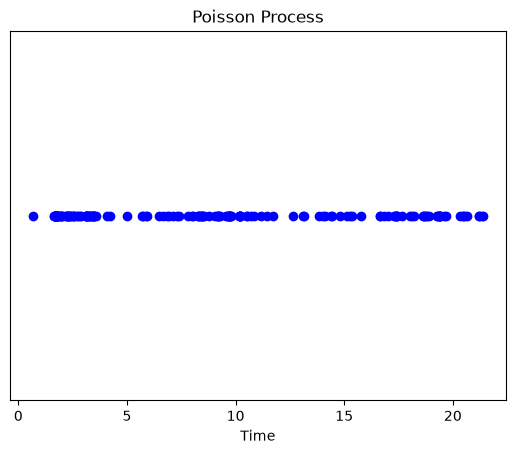

In [9]:

points = PoissonProcess(rate_values=rate_values, max_time=INTERVAL, time_delta= DELTA_T)
points.graph()